In [1]:
from utils import *

In [2]:
EJ=8.9
EC=2.5
EL=0.5
g_strength = 0.3

E_osc = 3

qubit_level = 8
osc_level = 50

In [3]:
qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=30,truncated_dim=qubit_level)
osc = scqubits.Oscillator(E_osc=E_osc,truncated_dim=osc_level)
hilbertspace = scqubits.HilbertSpace([qbt, osc])
hilbertspace.add_interaction(g_strength=g_strength,op1=qbt.n_operator,op2=osc.creation_operator,add_hc=True)
hilbertspace.generate_lookup()
product_to_dressed = generate_single_mapping(hilbertspace.hamiltonian())
# plot_specturum(qbt, osc, hilbertspace)

max overlap^2 0.015315063260411915 below threshold for dressed state 148 with eval 66.01994392158106


done:200/200


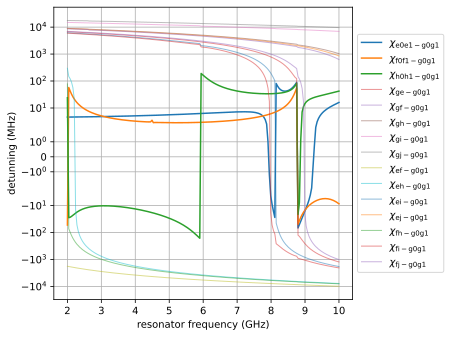

In [4]:
# sweep_resonator_frequency_for_ge_gf_gh_detunning(EJ=8.9,
#                                         EC=2.5,
#                                         EL=0.5,
#                                         flux = 0,
#                                         g_strength = 0.3)

In [4]:
a = hilbertspace.op_in_dressed_eigenbasis(op=osc.annihilation_operator)
a = qutip.Qobj(a[:, :])
 
(evals,) = hilbertspace["evals"]
diag_dressed_hamiltonian = (
        2 * np.pi * qutip.Qobj(np.diag(evals),
        dims=[hilbertspace.subsystem_dims] * 2)
)
diag_dressed_hamiltonian = qutip.Qobj(diag_dressed_hamiltonian[:, :])

leakage_dressed_state_osc_0 = product_to_dressed[(0,0)]
leakage_dressed_state_osc_1 = product_to_dressed[(0,1)]
w_d = transition_frequency(hilbertspace,leakage_dressed_state_osc_0,leakage_dressed_state_osc_1 )
# w_d = transition_frequency(hilbertspace,product_to_dressed[(0,0)], product_to_dressed[(0,1)])/2+transition_frequency(hilbertspace,product_to_dressed[(3,0)], product_to_dressed[(3,1)])/2


amp = 0.002
def square_cos(t,*args):
    cos = np.cos(w_d * 2*np.pi * t)
    return  2*np.pi *amp * cos

H_with_drive = [
    diag_dressed_hamiltonian,
    [a+a.dag(), square_cos]]

kappa = 0.03
decay_term = np.sqrt(kappa)*a

tot_time = 1000
tlist = np.linspace(0, tot_time, tot_time)[::4]


existing_chunk_num = 0
for i in range(4):
    existing_chunk_num = pack_mcsolve_chunks(H = H_with_drive,
                    state0 = qutip.basis(hilbertspace.dimension, product_to_dressed[(i,0)]),
                    tlist = tlist,
                    c_ops  = [decay_term],
                    ntraj = 700,
                    existing_chunk_num = existing_chunk_num,
                    chunk_size = 4)

def pack_pkl_files_to_zip(zip_filename="mcsolve_input.zip"):
    # Create a new ZIP file
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Loop through all files in the current directory
        for filename in os.listdir('.'):
            # Check if the file is a .pkl file with an integer name
            name, ext = os.path.splitext(filename)
            if ext == '.pkl' and name.isdigit():
                # Add the file to the ZIP
                zipf.write(filename)
                # Delete the .pkl file
                os.remove(filename)
                
pack_pkl_files_to_zip()

In [137]:
# !unzip mcsolve_input.zipx

In [5]:
import gzip
import pickle
import qutip
import numpy as np

# List of zip files containing the results
zip_files = [f"mcsolve_result_0.03/result_{i}.zip" for i in range(700)]

# Divide the files into four equal parts
n_parts = 4
part_length = len(zip_files) // n_parts
zip_file_parts = [zip_files[i * part_length: (i + 1) * part_length] for i in range(n_parts)]

# Initialize an empty list to store the four results
results = []

# Merge the results for each part and append to the results list
for part in zip_file_parts:
    results.append(merge_results(part))


done:175/175
(500, 400, 1)


In [9]:
import os
import re

def delete_files():
    # Loop through all files in the current directory
    for filename in os.listdir('mcsolve_input'):
        if filename.endswith('.pkl'):
            os.remove('mcsolve_input/'+filename)

delete_files()

interactive(children=(IntSlider(value=0, continuous_update=False, description='Index:', max=399), Output()), _…

 /Users/jiakaiwang/opt/miniconda3/envs/tensorflow/lib/python3.10/site-packages/jax/_src/array.py: 343

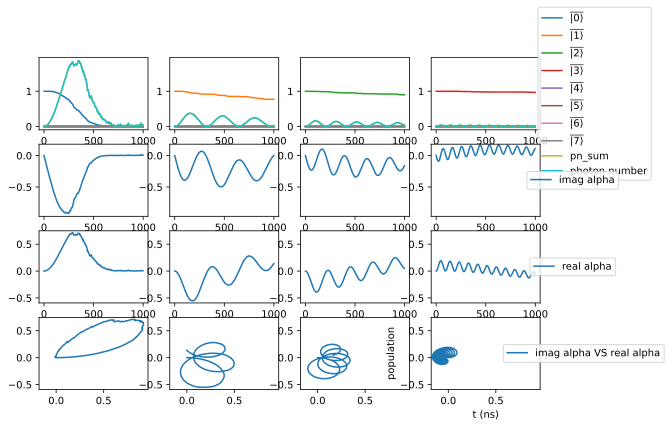

In [40]:
plot_population(results,qubit_level,osc_level,product_to_dressed,a,w_d,results[0].times,fourier=True)

In [ ]:
import qutip as qt

final_qubit_states = []
for initial_state in [0,1,2,3]:
    final_state = results[initial_state].states[-1]
    if final_state.type != 'oper':
        final_state = qt.ket2dm(qutip.Qobj(final_state))
    rho_product = qt.Qobj(dims = [[qubit_level,osc_level],[qubit_level,osc_level]])
    for (ql, ol), dressed_level in product_to_dressed.items():
        qubit_state = qt.basis(qubit_level, ql)
        osc_state = qt.basis(osc_level, ol)
        product_state = qt.tensor(qubit_state, osc_state)
        rho_product += product_state * product_state.dag() * final_state.data[dressed_level, dressed_level]
    qubit_rho = rho_product.ptrace(0)
    final_qubit_states.append(qubit_rho)
